Importar as Bibliotecas

In [ ]:
# --- IMPORTS ---
import re  # para limpar o texto usando expressões regulares
import numpy as np  # para trabalhar com vetores e médias
import pandas as pd  # para organizar os dados em tabela (DataFrame)
import matplotlib.pyplot as plt  # para gerar os gráficos
import os

from kagglehub import load_dataset
from wordcloud import WordCloud  # para gerar as nuvens de palavras

import nltk
from nltk.corpus import stopwords  # lista de palavras comuns (the, is, a...)
from nltk.tokenize import word_tokenize  # para separar o texto em palavras

from sklearn.model_selection import train_test_split  # para dividir treino/teste
from sklearn.feature_extraction.text import TfidfVectorizer  # para o TF-IDF
from sklearn.linear_model import LogisticRegression  # o classificador usado
# Inclusão de classification_report e matthews_corrcoef para lidar com as 3 classes
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, \
    matthews_corrcoef

!pip install gensim -qqq
from gensim.models import Word2Vec  # para treinar nosso próprio Word2Vec
import gensim.downloader as api  # para baixar o GloVe pré-treinado

# Downloads necessários do NLTK caso não estejam baixados
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

RANDOM_STATE = 42


Montar drive para carregar arquivos CSV

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Definir campo de amostragem**

In [ ]:
# Configuração da amostragem (ajustada para as 3 classes do novo dataset)
N_POR_CLASSE_PADRAO = 5000

print("CAMPO DE AMOSTRAGEM (FINANCIAL SENTIMENT)")
print("=" * 70)
print("Quantas frases de CADA classe (positive, neutral, negative) você quer usar?")
print(f"Pressione Enter para usar o valor padrão ({N_POR_CLASSE_PADRAO} por classe).")
print("Nota: Se digitar um valor maior do que o disponível em uma classe, usaremos o máximo dela.")

entrada_usuario = input("Quantidade por classe: ").strip()

try:
    if entrada_usuario == "":
        N_POR_CLASSE = N_POR_CLASSE_PADRAO
    else:
        valor_digitado = int(entrada_usuario)
        if valor_digitado <= 0:
            print("Valor inválido (precisa ser maior que zero). Usando o padrão.")
            N_POR_CLASSE = N_POR_CLASSE_PADRAO
        else:
            N_POR_CLASSE = valor_digitado
except ValueError:
    print("Entrada não é um número. Usando o valor padrão.")
    N_POR_CLASSE = N_POR_CLASSE_PADRAO


CAMPO DE AMOSTRAGEM (FINANCIAL SENTIMENT)
Quantas frases de CADA classe (positive, neutral, negative) você quer usar?
Pressione Enter para usar o valor padrão (5000 por classe).
Nota: Se digitar um valor maior do que o disponível em uma classe, usaremos o máximo dela.
Quantidade por classe: 


**SEÇÃO 1 - CARREGAMENTO E PROPORÇÃO DOS DADOS (KAGGLE CSV)**

In [ ]:
# SEÇÃO 1 - CARREGAMENTO E PROPORÇÃO DOS DADOS (KAGGLE CSV)
# =====================================================================

print("\nSEÇÃO 1 - Carregando os dados...")

# Caminho completo para o arquivo CSV fornecido pelo usuário
nome_arquivo = "/content/drive/MyDrive/CETAM/LLM/trabalho_final/data.csv"

# Lendo o dataset do Kaggle (Colunas originais: Sentence e Sentiment)
df_bruto = pd.read_csv(nome_arquivo)

# Estratégia de Amostragem Controlada para as 3 classes
classes = ['neutral', 'positive', 'negative']
amostras = []

for c in classes:
    df_classe = df_bruto[df_bruto['Sentiment'] == c]
    # Garante que não vai pedir mais amostras do que a classe realmente tem disponível
    limite = min(N_POR_CLASSE, len(df_classe))
    amostras.append(df_classe.sample(n=limite, random_state=RANDOM_STATE))

# Une as classes amostradas e embaralha o DataFrame final
df = pd.concat(amostras).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Renomeando as colunas internamente para manter compatibilidade lógica com o código antigo
df = df.rename(columns={"Sentence": "content", "Sentiment": "label"})

print("Total de frases amostradas:", len(df))
print(df["label"].value_counts())


SEÇÃO 1 - Carregando os dados...
Total de frases amostradas: 5842
label
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64


**SEÇÃO 2 - ANÁLISE EXPLORATÓRIA (EDA) E LIMPEZA**


SEÇÃO 2 - Análise exploratória e Limpeza

Valores nulos:
content    0
label      0
dtype: int64
Frases duplicadas encontradas: 520
Total depois de limpar nulos/duplicatas: 5322


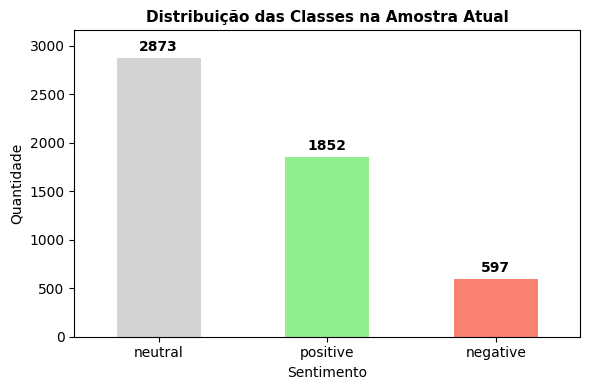

In [ ]:
# SEÇÃO 2 - ANÁLISE EXPLORATÓRIA (EDA) E LIMPEZA
# =====================================================================

print("\nSEÇÃO 2 - Análise exploratória e Limpeza")

print("\nValores nulos:")
print(df.isnull().sum())

duplicatas = df.duplicated(subset=["content"]).sum()
print("Frases duplicadas encontradas:", duplicatas)

df = df.drop_duplicates(subset=["content"])
df = df.dropna(subset=["content"])
df = df.reset_index(drop=True)
print("Total depois de limpar nulos/duplicatas:", len(df))

# Mapeamento de contrações em inglês adaptado do código original
contracoes = {
    "don't": "do not", "didn't": "did not", "doesn't": "does not",
    "isn't": "is not", "wasn't": "was not", "can't": "cannot",
    "won't": "will not", "it's": "it is", "i'm": "i am",
    "i've": "i have", "i'll": "i will",
}


def limpar_texto(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r"<[^>]*>", " ", texto)  # remove tags HTML se houver

    for errada, certa in contracoes.items():
        texto = texto.replace(errada, certa)

    texto = re.sub(r"[^a-z0-9\s]", " ", texto)  # remove pontuações
    texto = re.sub(r"\s+", " ", texto).strip()  # remove espaços extras

    palavras = texto.split()
    palavras = [p for p in palavras if len(p) > 1 or p in ("a", "i")]
    texto = " ".join(palavras)

    return texto


# Executa a limpeza na coluna de textos financeiros
df["content"] = df["content"].apply(limpar_texto)

# Gráfico de distribuição das classes atuais com rótulos numéricos
plt.figure(figsize=(6, 4))

# Capturamos o eixo (ax) ao plotar o gráfico de barras
ax = df["label"].value_counts().plot(kind="bar", color=["lightgray", "lightgreen", "salmon"])


ax.bar_label(ax.containers[0], padding=3, fontsize=10, fontweight='bold')

plt.title("Distribuição das Classes na Amostra Atual", fontsize=11, fontweight='bold')
plt.ylabel("Quantidade")
plt.xlabel("Sentimento")
plt.xticks(rotation=0)

# Ajusta os limites do eixo Y para que o número de cima da barra mais alta não seja cortado
plt.ylim(0, df["label"].value_counts().max() * 1.1)

plt.tight_layout()

# Salva a imagem em alta resolução para colar no banner do CETAM
plt.savefig('grafico_distribuicao_cetam.png', dpi=300, bbox_inches='tight')

plt.show()



**SEÇÃO 3 - PROCESSAMENTO E PREPARAÇÃO DOS EMBEDDINGS**

In [ ]:
# SEÇÃO 3 - PROCESSAMENTO E PREPARAÇÃO DOS EMBEDDINGS
# =====================================================================

print("\nSEÇÃO 3 - Preparando Tokenização e Modelos de Linguagem...")

# Tokenização para os algoritmos de embedding
stop_words = set(stopwords.words('english'))
nltk.download('punkt_tab', quiet=True)
df['tokens'] = df['content'].apply(lambda x: [w for w in word_tokenize(x) if w not in stop_words])


# Divisão de Treino e Teste (80% treino / 20% teste)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['content'], df['label'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['label']
)
_, _, tokens_train, tokens_test = train_test_split(
    df['content'], df['tokens'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['label']
)

# --- 3.1 Extração TF-IDF ---
tfidf_vec = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vec.fit_transform(X_train_text)
X_test_tfidf = tfidf_vec.transform(X_test_text)

# --- 3.2 Treinamento Word2Vec Próprio ---
print("Treinando modelo Word2Vec customizado...")
w2v_model = Word2Vec(sentences=tokens_train, vector_size=100, window=5, min_count=2, workers=4, seed=RANDOM_STATE)

# --- 3.3 Download do GloVe Pré-treinado ---
print("Baixando/Carregando vetores do GloVe (glove-wiki-gigaword-100)...")
glove_model = api.load("glove-wiki-gigaword-100")


# Função auxiliar para transformar uma lista de palavras no vetor médio da frase
def vetorizar_texto(tokens, modelo, dimensao=100):
    vetores = []
    for token in tokens:
        if isinstance(modelo, Word2Vec):
            if token in modelo.wv:
                vetores.append(modelo.wv[token])
        else:  # Para o GloVe da Gensim API
            if token in modelo:
                vetores.append(modelo[token])

    if len(vetores) == 0:
        return np.zeros(dimensao)
    return np.mean(vetores, axis=0)


# Gerando matrizes de embeddings de treino/teste para Word2Vec e GloVe
X_train_w2v = np.array([vetorizar_texto(t, w2v_model) for t in tokens_train])
X_test_w2v = np.array([vetorizar_texto(t, w2v_model) for t in tokens_test])

X_train_glove = np.array([vetorizar_texto(t, glove_model) for t in tokens_train])
X_test_glove = np.array([vetorizar_texto(t, glove_model) for t in tokens_test])

print('Feito!')


SEÇÃO 3 - Preparando Tokenização e Modelos de Linguagem...
Treinando modelo Word2Vec customizado...
Baixando/Carregando vetores do GloVe (glove-wiki-gigaword-100)...
Feito!


**SEÇÃO 4 - TREINAMENTO, VALIDAÇÃO E MÉTRICAS COMPARATIVAS**


SEÇÃO 4 - Executando Treinamento e Avaliação das Métricas...

RELATÓRIO DE DESEMPENHO: TF-IDF
              precision    recall  f1-score   support

     neutral       0.68      0.25      0.37       119
    positive       0.76      0.90      0.82       575
    negative       0.75      0.69      0.72       371

    accuracy                           0.75      1065
   macro avg       0.73      0.61      0.64      1065
weighted avg       0.75      0.75      0.73      1065

Matthews Correlation Coefficient (MCC): 0.5499

RELATÓRIO DE DESEMPENHO: Word2Vec (Custom)
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00       119
    positive       0.58      0.94      0.71       575
    negative       0.53      0.18      0.27       371

    accuracy                           0.57      1065
   macro avg       0.37      0.37      0.33      1065
weighted avg       0.50      0.57      0.48      1065

Matthews Correlation Coefficient (MCC): 0.1522

RELA

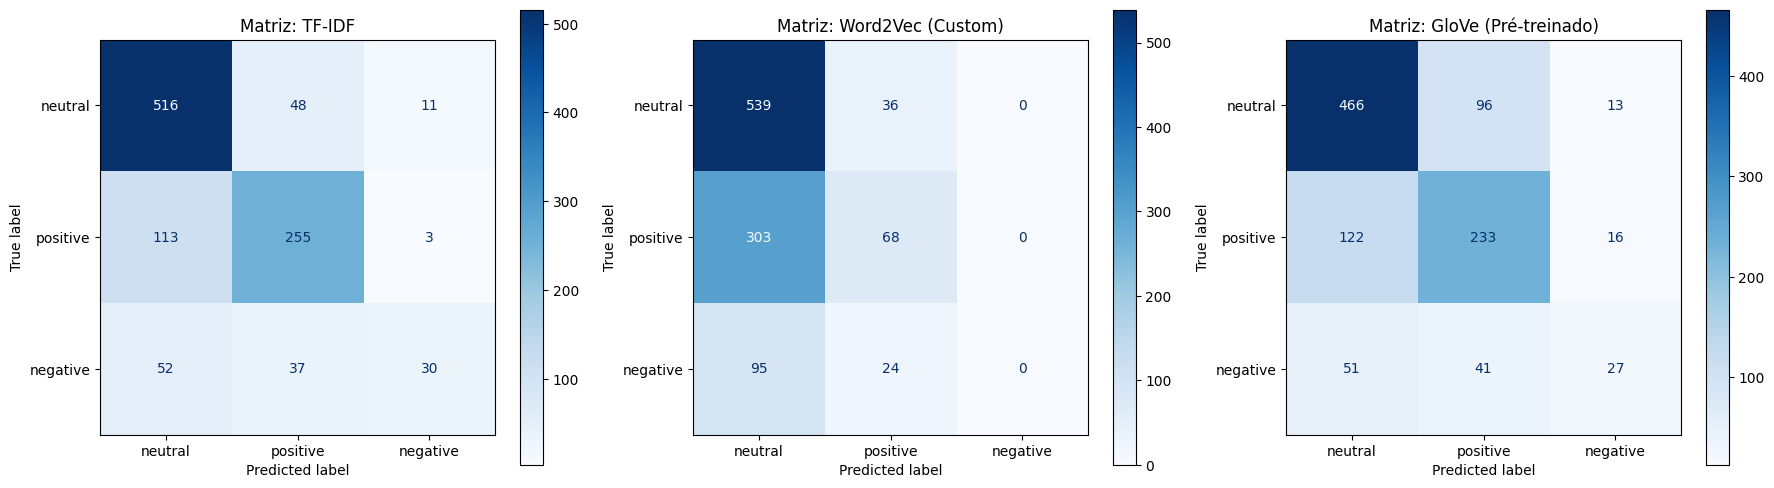

In [ ]:
# SEÇÃO 4 - TREINAMENTO, VALIDAÇÃO E MÉTRICAS COMPARATIVAS
# =====================================================================

print("\nSEÇÃO 4 - Executando Treinamento e Avaliação das Métricas...")

cenarios = {
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
    "Word2Vec (Custom)": (X_train_w2v, X_test_w2v),
    "GloVe (Pré-treinado)": (X_train_glove, X_test_glove)
}

# Dicionário para consolidar os resultados das métricas
resultados_consolidados = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (nome_cenario, (X_tr, X_te)) in enumerate(cenarios.items()):
    # Regressão Logística configurada para lidar explicitamente com multiclasse (multinomial)
    # Modificado para funcionar nas versões mais recentes do Scikit-Learn
    modelo_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    modelo_lr.fit(X_tr, y_train)

    # Previsões
    y_pred = modelo_lr.predict(X_te)

    # Cálculo das métricas solicitadas para o problema multiclasse
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    mcc = matthews_corrcoef(y_test, y_pred)

    resultados_consolidados.append({
        "Abordagem": nome_cenario,
        "Acurácia": acc,
        "F1-Score (Macro)": f1_macro,
        "MCC": mcc
    })

    print(f"\n" + "=" * 50)
    print(f"RELATÓRIO DE DESEMPENHO: {nome_cenario}")
    print("=" * 50)
    # Adicionado zero_division=0 para tratar partições onde o modelo não previu uma das classes
    print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

    # Renderização da Matriz de Confusão para análise visual de erros de previsão
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f"Matriz: {nome_cenario}")

plt.tight_layout()
plt.show()


**5. GERAÇÃO DO GRÁFICO COMPARATIVO (F1-SCORE VS ACURÁCIA)**


Gerando gráfico comparativo de F1-Score e Acurácia para o banner...

Gerando gráfico comparativo de F1-Score e Acurácia para o banner...
Gráfico 'grafico_metricas_comparativas_cetam.png' exportado com sucesso!


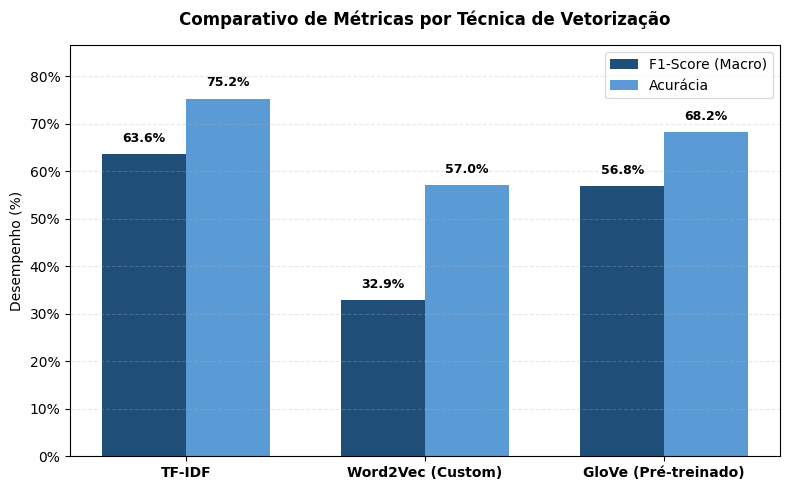

In [ ]:
# GERAÇÃO DO GRÁFICO COMPARATIVO (F1-SCORE VS ACURÁCIA)
# =====================================================================

print("\nGerando gráfico comparativo de F1-Score e Acurácia para o banner...")
# --- Certificando a criação do DataFrame de resultados ---
df_resultados = pd.DataFrame(resultados_consolidados)


print("\nGerando gráfico comparativo de F1-Score e Acurácia para o banner...")
abordagens = df_resultados["Abordagem"].tolist()
f1_scores = df_resultados["F1-Score (Macro)"].tolist()
acuracias = df_resultados["Acurácia"].tolist()



abordagens = df_resultados["Abordagem"].tolist()
f1_scores = df_resultados["F1-Score (Macro)"].tolist()
acuracias = df_resultados["Acurácia"].tolist()

x = np.arange(len(abordagens))  # As localizações dos grupos no eixo X
largura_barra = 0.35            # A largura de cada barra individual

# 2. Inicializa a figura do gráfico
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Plota as barras de F1-Score e Acurácia lado a lado
# Cores profissionais: Azul escuro para F1-Score e Azul claro/ciano para Acurácia
barras_f1 = ax.bar(x - largura_barra/2, f1_scores, largura_barra, label='F1-Score (Macro)', color='#1f4e79')
barras_acc = ax.bar(x + largura_barra/2, acuracias, largura_barra, label='Acurácia', color='#5b9bd5')

# 4. --- NOVA ETAPA: Adiciona os rótulos numéricos (%) em cima de cada barra ---
def adicionar_rotulos(barras):
    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width()/2.,     # Posição X: centro da barra específica
            altura + 0.02,                             # Posição Y: levemente acima da barra
            f'{altura:.1%}',                           # Formato de porcentagem com 1 casa (ex: 75.4%)
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='black'
        )

adicionar_rotulos(barras_f1)
adicionar_rotulos(barras_acc)

# 5. Customização e Formatação Estética do Eixo e Legendas
ax.set_title("Comparativo de Métricas por Técnica de Vetorização", fontsize=12, fontweight='bold', pad=15)
ax.set_ylabel("Desempenho (%)", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(abordagens, fontsize=10, fontweight='bold')

# Posiciona a legenda de identificação das cores no topo
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='lightgray')

# Altera a escala do eixo Y para exibir o símbolo de porcentagem (0% a 100%)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Define a altura limite do eixo Y com folga para que as porcentagens superiores não sumam
maior_valor = max(max(f1_scores), max(acuracias))
ax.set_ylim(0, maior_valor * 1.15)

# Adiciona linhas de grade discretas horizontais ao fundo
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

# Salva o arquivo final em altíssima resolução para a impressão física do banner do CETAM
nome_grafico_salvar = 'grafico_metricas_comparativas_cetam.png'
plt.savefig(nome_grafico_salvar, dpi=300, bbox_inches='tight')
print(f"Gráfico '{nome_grafico_salvar}' exportado com sucesso!")

plt.show()

